In [5]:
from datetime import date
from pathlib import Path
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import *
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from shapely import wkt

SITE_DATA_DIR = Path("../data/processed/traffic_site/top_100_sites.csv")
VOLUME_DATA_DIR = "../data/processed/traffic_volume"

AO_DATES = {2020: (date(2020, 1, 13), date(2020, 2, 2)),
            2021: (date(2021, 2, 1),  date(2021, 2, 21)), 
            2022: (date(2022, 1, 10), date(2022, 1, 30)),
            2023: (date(2023, 1, 9), date(2023, 1, 29)),
            2024: (date(2024, 1, 7), date(2024, 1, 28)),
            2025: (date(2025, 1, 5), date(2025, 1, 26))}

In [6]:
# ---------------------------------------------------------------------------------------------------------------
# PLOT TOP 100 CLOSEST TRAFFIC SITES
# ---------------------------------------------------------------------------------------------------------------
site_df = pd.read_csv(SITE_DATA_DIR)
site_df["geometry"] = site_df["geometry"].apply(wkt.loads)
site_gdf = gpd.GeoDataFrame(site_df, geometry="geometry", crs="EPSG:4326")

# Create map
centre = [site_gdf.geometry.y.mean(), site_gdf.geometry.x.mean()]
map = folium.Map(location=centre, zoom_start=12)

# Plot traffic sites
for row in site_gdf.itertuples():
    folium.CircleMarker(location=[row.geometry.y, row.geometry.x],
                        radius=4,
                        fill=True,
                        popup=f"Site: {row.site_id}, Name: {row.site_name}").add_to(map)

map

In [7]:
# ---------------------------------------------------------------------------------------------------------------
# BEGIN SPARK SESSION
# ---------------------------------------------------------------------------------------------------------------
spark = SparkSession.builder.getOrCreate()

df = spark.read.parquet(VOLUME_DATA_DIR)

# Change schema 
new_schema = StructType([StructField("date", DateType()),
                         StructField("hour", IntegerType()),
                         StructField("site_id", IntegerType()),
                         StructField("volume", IntegerType())])
df = df.to(new_schema)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/15 01:51:05 WARN Utils: Your hostname, MSI, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/15 01:51:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/15 01:51:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


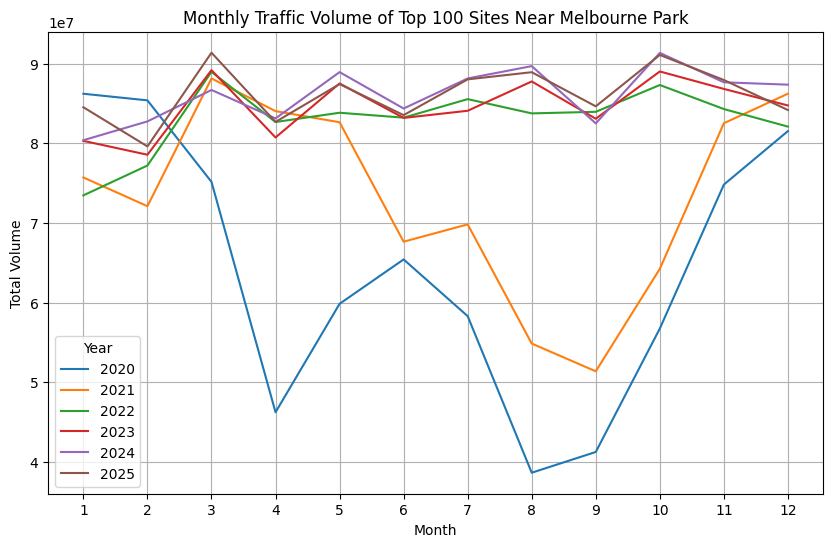

In [ ]:
# ---------------------------------------------------------------------------------------------------------------
# VISUALISE MONTHLY TOTAL TRAFFIC VOLUME
# ---------------------------------------------------------------------------------------------------------------
# Sum volume by day
total_daily_volume = df.select("date", "volume") \
                         .groupBy("date") \
                         .agg(F.sum("volume").alias("total_daily_volume")) \
                         .sort("date")

# Remove single outlier
total_daily_volume = total_daily_volume[total_daily_volume["total_daily_volume"] < 5000000]

# Convert Sparks dataframe to Pandas
total_daily_volume = total_daily_volume.toPandas()
total_daily_volume["date"] = pd.to_datetime(total_daily_volume["date"])
total_daily_volume["year"] = total_daily_volume["date"].dt.year
total_daily_volume["month"] = total_daily_volume["date"].dt.month
total_daily_volume["month_day"] = total_daily_volume["date"].dt.strftime("%m-%d")

def find_ao_day(row):
    start, _ = AO_DATES[row.year]
    return (row.date.date() - start).days + 1

total_daily_volume["ao_day"] = total_daily_volume.apply(find_ao_day, axis=1)

# Sum volume by month
total_monthly_volume = total_daily_volume[["year", "month", "total_daily_volume"]].groupby(["year", "month"], as_index=False).sum()
total_monthly_volume.rename(columns={"total_daily_volume": "total_monthly_volume"}, inplace=True)

plt.figure(figsize=(10, 6))

for year in range(2020, 2026):

    year_df = total_monthly_volume[total_monthly_volume["year"] == year]

    plt.plot(year_df["month"], 
             year_df["total_monthly_volume"],
             label=str(year))
    
plt.xlabel("Month")
plt.ylabel("Total Volume")
plt.title("Monthly Traffic Volume of Top 100 Sites Near Melbourne Park")
plt.xticks(range(1,13))
plt.legend(title="Year")
plt.grid(True)
plt.show()

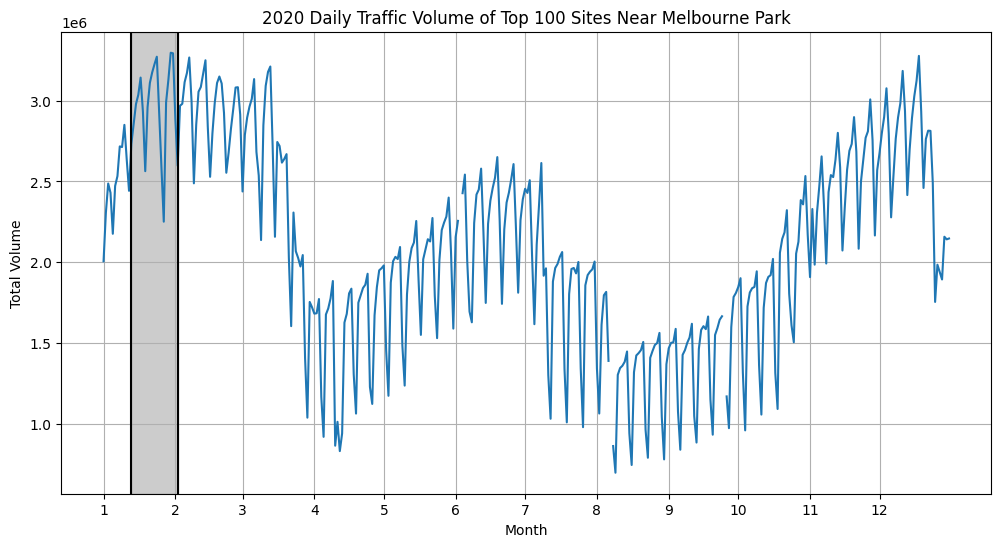

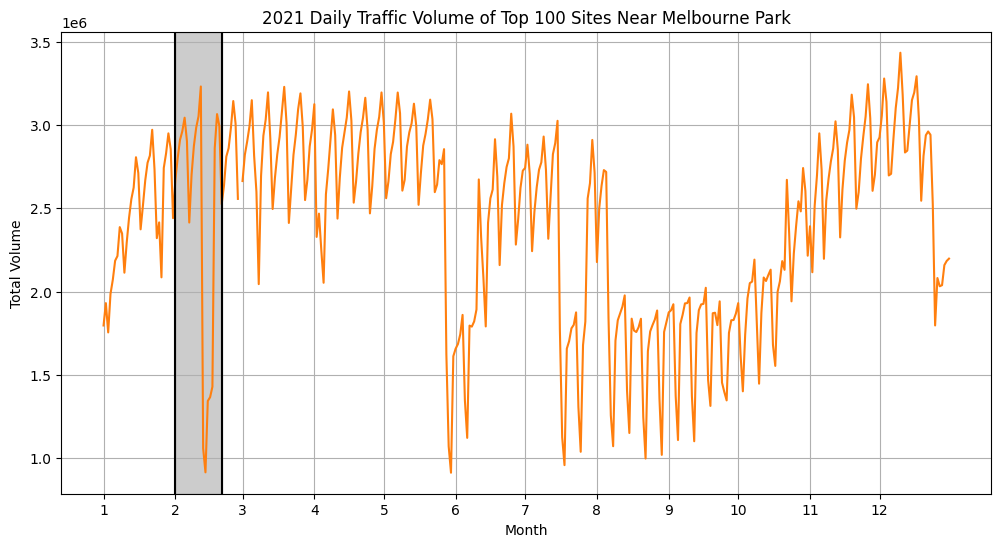

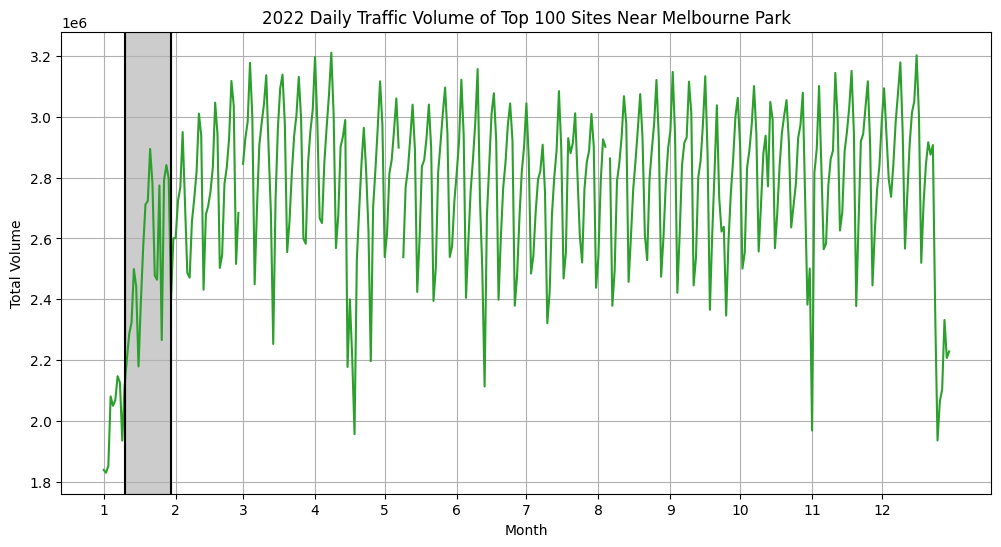

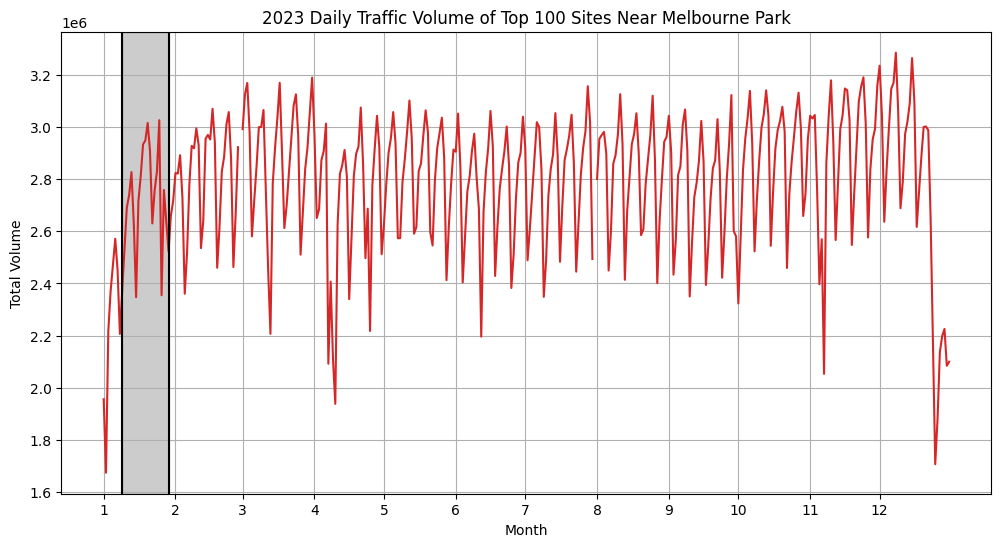

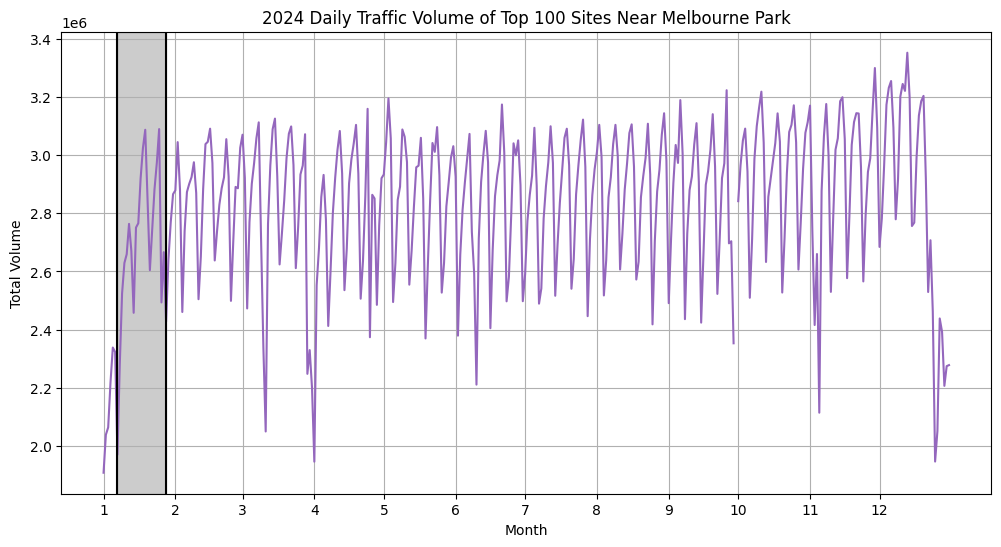

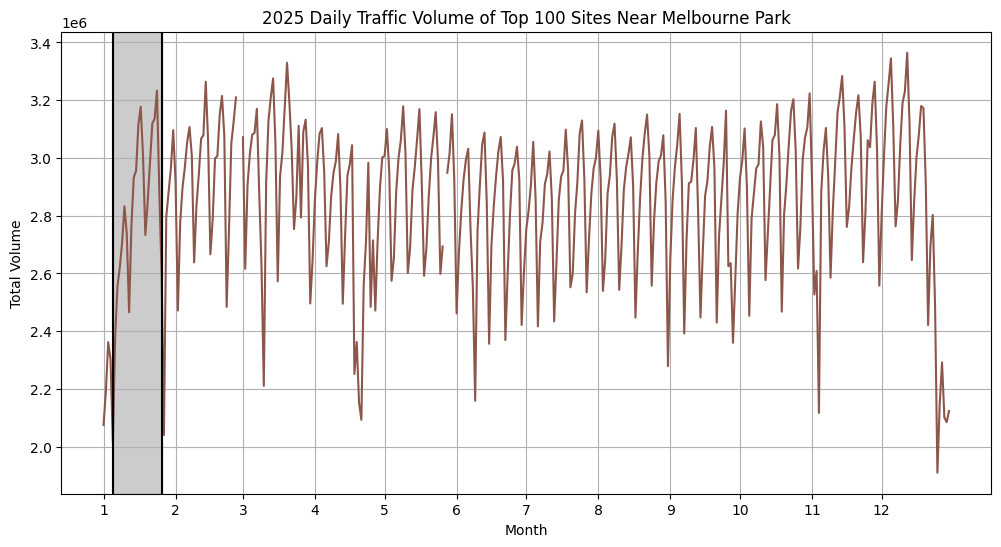

In [9]:
# ---------------------------------------------------------------------------------------------------------------
# VISUALISE DAILY TOTAL TRAFFIC VOLUME
# ---------------------------------------------------------------------------------------------------------------
pivot = total_daily_volume.pivot(index="month_day",
                                 columns="year",
                                 values="total_daily_volume").sort_index()

month_starts = [
    "01-01", "02-01", "03-01", "04-01",
    "05-01", "06-01", "07-01", "08-01",
    "09-01", "10-01", "11-01", "12-01"
]

colors = list(mcolors.TABLEAU_COLORS.keys())

for i, year in enumerate(pivot.columns):

    plt.figure(figsize=(12, 6))

    plt.plot(pivot.index, 
             pivot[year],
             color=colors[i])
    
    start_date = AO_DATES[year][0].strftime("%m-%d")
    end_date = AO_DATES[year][1].strftime("%m-%d")
    
    plt.axvline(start_date, color="black")
    plt.axvline(end_date, color="black")
    plt.axvspan(start_date, end_date, color="black", alpha=0.2)

    plt.xlabel("Month")
    plt.ylabel("Total Volume")
    plt.title(f"{year} Daily Traffic Volume of Top 100 Sites Near Melbourne Park")
    plt.xticks(month_starts, range(1,13))
    plt.grid(True)
    plt.show()

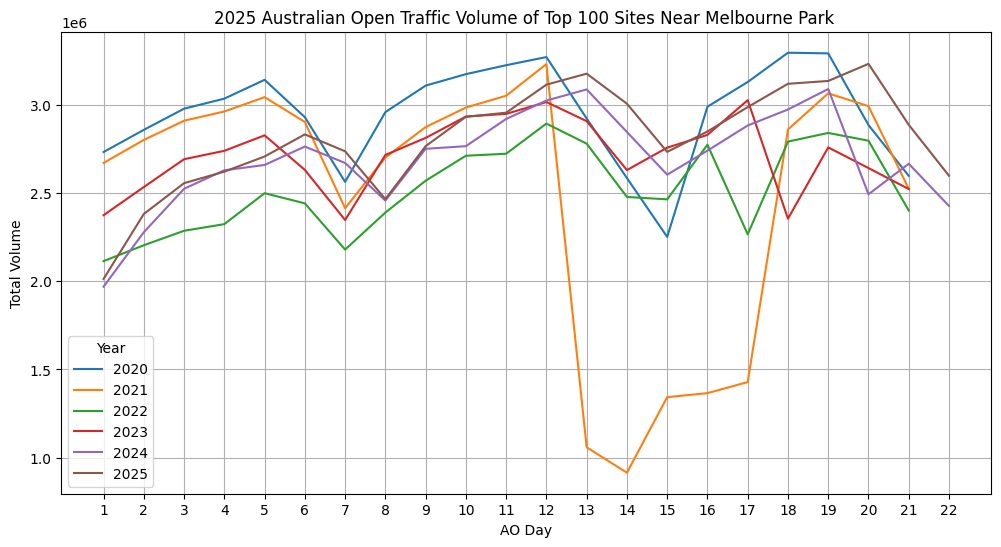

In [22]:
# ---------------------------------------------------------------------------------------------------------------
# VISUALISE TRAFFIC VOLUME DURING AUSTRALIAN OPEN
# ---------------------------------------------------------------------------------------------------------------
mask = pd.Series(False, index=total_daily_volume.index)

for start, end in AO_DATES.values():
    mask |= (total_daily_volume["date"].dt.date >= start) & (total_daily_volume["date"].dt.date <= end)

ao_volume = total_daily_volume.loc[mask]

plt.figure(figsize=(12, 6))

for year in range(2020, 2026):

    year_df = ao_volume[ao_volume["year"] == year]

    plt.plot(year_df["ao_day"], 
             year_df["total_daily_volume"],
             label=str(year))
    
plt.xlabel("AO Day")
plt.ylabel("Total Volume")
plt.title(f"{year} Australian Open Traffic Volume of Top 100 Sites Near Melbourne Park ")
plt.xticks(year_df["ao_day"])
plt.legend(title="Year")
plt.grid(True)
plt.show()